<a href="https://colab.research.google.com/github/suphisarameephio/ItBru/blob/main/Credit_Score_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Data

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Read the dataset
df = pd.read_csv('/content/Score.csv')

# Display first few rows
df.head(10)


,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Monthly_Balance,Age,Annual_Income,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Monthly_Inhand_Salary,Changed_Credit_Limit,Outstanding_Debt,Total_EMI_per_month,Credit_Score
0,3,7,4,26.822620,265,No,80.415295,312.494089,23,19114.12,3,4,3,4,1824.843333,11.27,809.98,49.574949,Good
1,3,7,4,31.944960,265,No,118.280222,284.629163,23,19114.12,3,4,3,4,1824.843333,11.27,809.98,49.574949,Good
2,3,7,4,28.609352,267,No,81.699521,331.209863,23,19114.12,3,4,3,4,1824.843333,11.27,809.98,49.574949,Good
3,5,4,4,31.377862,268,No,199.458074,223.451310,23,19114.12,3,4,3,4,1824.843333,11.27,809.98,49.574949,Good
4,6,4,4,24.797347,269,No,41.420153,341.489231,23,19114.12,3,4,3,4,1824.843333,11.27,809.98,49.574949,Good
5,8,4,4,27.262259,270,No,62.430172,340.479212,23,19114.12,3,4,3,4,1824.843333,11.27,809.98,49.574949,Good
6,3,8,4,22.537593,271,No,178.344067,244.565317,23,19114.12,3,4,3,4,1824.843333,11.27,809.98,49.574949,Good
7,3,6,4,23.933795,271,No,24.785217,358.124168,23,19114.12,3,4,3,4,1824.843333,11.27,809.98,49.574949,Standard
8,3,4,2,24.464031,319,No,104.291825,470.690627,28,34847.84,2,4,6,1,3037.986667,5.42,605.03,18.816215,Standard
9,7,1,2,38.550848,320,No,40.391238,484.591214,28,34847.84,2,4,6,1,3037.986667,5.42,605.03,18.816215,Good


# Data Preprocessing

In [3]:
# Check for missing values
df.isnull().sum()

,0
Delay_from_due_date,0
Num_of_Delayed_Payment,0
Num_Credit_Inquiries,0
Credit_Utilization_Ratio,0
Credit_History_Age,0
Payment_of_Min_Amount,0
Amount_invested_monthly,0
Monthly_Balance,0
Age,0
Annual_Income,0


In [4]:
# Drop rows with any null values
df.dropna(inplace=True)

In [5]:
# Display basic statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Delay_from_due_date,87954.0,21.089206,14.831230,0.000000,10.000000,18.000000,28.000000,67.000000
Num_of_Delayed_Payment,87954.0,13.333424,6.271498,0.000000,9.000000,14.000000,18.000000,28.000000
Num_Credit_Inquiries,87954.0,5.771597,3.861902,0.000000,3.000000,5.000000,8.000000,26.000000
Credit_Utilization_Ratio,87954.0,32.289680,5.119080,20.000000,28.049710,32.306187,36.505310,50.000000
Credit_History_Age,87954.0,220.995930,99.588523,1.000000,144.000000,219.000000,302.000000,404.000000
Amount_invested_monthly,87954.0,193.568688,194.686294,0.000000,73.482469,129.228926,234.500707,1977.326102
Monthly_Balance,87954.0,403.210112,213.921167,0.007760,270.258355,337.049632,471.950383,1602.040519
Age,87954.0,33.294313,10.773035,14.000000,24.000000,33.000000,42.000000,56.000000
Annual_Income,87954.0,50462.223903,38254.583037,7005.930000,19328.710000,36980.100000,71681.400000,179987.280000
Num_Bank_Accounts,87954.0,5.369238,2.589168,0.000000,3.000000,5.000000,7.000000,10.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87954 entries, 0 to 87953
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Delay_from_due_date       87954 non-null  int64  
 1   Num_of_Delayed_Payment    87954 non-null  int64  
 2   Num_Credit_Inquiries      87954 non-null  int64  
 3   Credit_Utilization_Ratio  87954 non-null  float64
 4   Credit_History_Age        87954 non-null  int64  
 5   Payment_of_Min_Amount     87954 non-null  object 
 6   Amount_invested_monthly   87954 non-null  float64
 7   Monthly_Balance           87954 non-null  float64
 8   Age                       87954 non-null  int64  
 9   Annual_Income             87954 non-null  float64
 10  Num_Bank_Accounts         87954 non-null  int64  
 11  Num_Credit_Card           87954 non-null  int64  
 12  Interest_Rate             87954 non-null  int64  
 13  Num_of_Loan               87954 non-null  int64  
 14  Monthl

In [7]:
from sklearn import preprocessing

# List of columns to encode
columns_to_encode = ['Payment_of_Min_Amount']

# Create a LabelEncoder instance
label_encoder = preprocessing.LabelEncoder()

# Loop through columns and apply Label Encoding
for column in columns_to_encode:
    df[column] = label_encoder.fit_transform(df[column])

    # Get and print the mapping for each column
    le_name_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
    print(f"Mapping for {column}: {le_name_mapping}")

Mapping for Payment_of_Min_Amount: {'No': np.int64(0), 'Yes': np.int64(1)}


In [8]:
df

,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Monthly_Balance,Age,Annual_Income,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Monthly_Inhand_Salary,Changed_Credit_Limit,Outstanding_Debt,Total_EMI_per_month,Credit_Score
0,3,7,4,26.822620,265,0,80.415295,312.494089,23,19114.12,3,4,3,4,1824.843333,11.27,809.98,49.574949,Good
1,3,7,4,31.944960,265,0,118.280222,284.629163,23,19114.12,3,4,3,4,1824.843333,11.27,809.98,49.574949,Good
2,3,7,4,28.609352,267,0,81.699521,331.209863,23,19114.12,3,4,3,4,1824.843333,11.27,809.98,49.574949,Good
3,5,4,4,31.377862,268,0,199.458074,223.451310,23,19114.12,3,4,3,4,1824.843333,11.27,809.98,49.574949,Good
4,6,4,4,24.797347,269,0,41.420153,341.489231,23,19114.12,3,4,3,4,1824.843333,11.27,809.98,49.574949,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87949,23,7,3,34.663572,378,0,60.971333,479.866228,25,39628.99,4,6,7,2,3359.415833,11.50,502.38,35.104023,Poor
87950,18,7,3,40.565631,379,0,54.185950,496.651610,25,39628.99,4,6,7,2,3359.415833,11.50,502.38,35.104023,Poor
87951,27,6,3,41.255522,380,0,24.028477,516.809083,25,39628.99,4,6,7,2,3359.415833,11.50,502.38,35.104023,Poor
87952,20,6,3,33.638208,381,0,251.672582,319.164979,25,39628.99,4,6,7,2,3359.415833,11.50,502.38,35.104023,Standard


In [9]:
from sklearn.preprocessing import OrdinalEncoder

# Create an OrdinalEncoder instance
ordinal_encoder = OrdinalEncoder(categories=[['Poor', 'Standard', 'Good']]) # Specify the order

# Fit and transform the 'Credit_Score' column
df['Credit_Score'] = ordinal_encoder.fit_transform(df[['Credit_Score']])


In [10]:
# Print the mapping (optional)
credit_score_mapping = dict(zip(ordinal_encoder.categories_[0], ordinal_encoder.transform([[c] for c in ordinal_encoder.categories_[0]]).flatten()))
print(f"Mapping for Credit_Score: {credit_score_mapping}")

Mapping for Credit_Score: {'Poor': np.float64(0.0), 'Standard': np.float64(1.0), 'Good': np.float64(2.0)}


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


<Axes: >

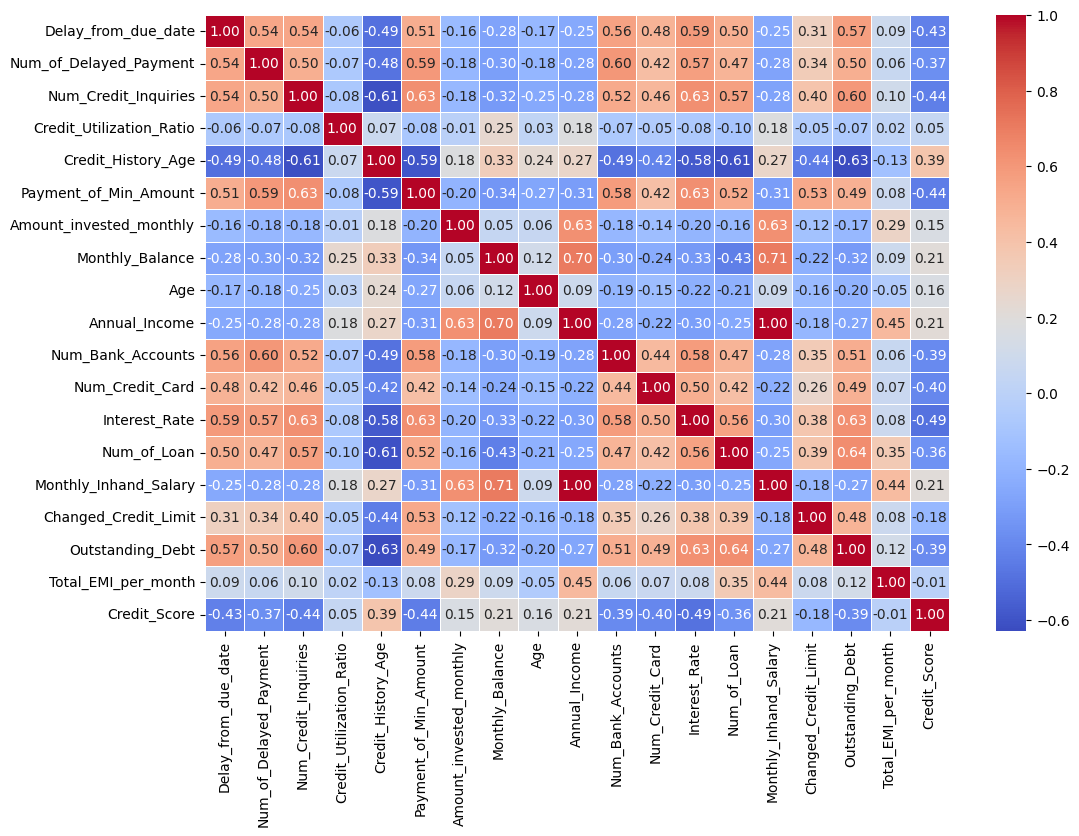

In [11]:
# Visualize correlation matrix for feature selection
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(),annot=True,fmt=".2f", linewidth=.5,cmap='coolwarm')

In [12]:
features = [col for col in df.corr().index[abs(df.corr()['Credit_Score']) >= 0.2] if col != 'Credit_Score']
print(features)

['Delay_from_due_date', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Monthly_Balance', 'Annual_Income', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Monthly_Inhand_Salary', 'Outstanding_Debt']


In [13]:
X = df[features] #features
y = df['Credit_Score'] #label

In [14]:
X

,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Credit_History_Age,Payment_of_Min_Amount,Monthly_Balance,Annual_Income,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Monthly_Inhand_Salary,Outstanding_Debt
0,3,7,4,265,0,312.494089,19114.12,3,4,3,4,1824.843333,809.98
1,3,7,4,265,0,284.629163,19114.12,3,4,3,4,1824.843333,809.98
2,3,7,4,267,0,331.209863,19114.12,3,4,3,4,1824.843333,809.98
3,5,4,4,268,0,223.451310,19114.12,3,4,3,4,1824.843333,809.98
4,6,4,4,269,0,341.489231,19114.12,3,4,3,4,1824.843333,809.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...
87949,23,7,3,378,0,479.866228,39628.99,4,6,7,2,3359.415833,502.38
87950,18,7,3,379,0,496.651610,39628.99,4,6,7,2,3359.415833,502.38
87951,27,6,3,380,0,516.809083,39628.99,4,6,7,2,3359.415833,502.38
87952,20,6,3,381,0,319.164979,39628.99,4,6,7,2,3359.415833,502.38


In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
X_scaled

,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Credit_History_Age,Payment_of_Min_Amount,Monthly_Balance,Annual_Income,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Monthly_Inhand_Salary,Outstanding_Debt
0,-1.219677,-1.009880,-0.458739,0.441861,-1.21189,-0.424065,-0.819465,-0.915063,-0.741600,-1.317642,0.189927,-0.744181,-0.533272
1,-1.219677,-1.009880,-0.458739,0.441861,-1.21189,-0.554324,-0.819465,-0.915063,-0.741600,-1.317642,0.189927,-0.744181,-0.533272
2,-1.219677,-1.009880,-0.458739,0.461944,-1.21189,-0.336576,-0.819465,-0.915063,-0.741600,-1.317642,0.189927,-0.744181,-0.533272
3,-1.084826,-1.488237,-0.458739,0.471985,-1.21189,-0.840309,-0.819465,-0.915063,-0.741600,-1.317642,0.189927,-0.744181,-0.533272
4,-1.017400,-1.488237,-0.458739,0.482027,-1.21189,-0.288523,-0.819465,-0.915063,-0.741600,-1.317642,0.189927,-0.744181,-0.533272
...,...,...,...,...,...,...,...,...,...,...,...,...,...
87949,0.128837,-1.009880,-0.717681,1.576537,-1.21189,0.358340,-0.283189,-0.528836,0.225624,-0.860090,-0.627174,-0.262118,-0.799592
87950,-0.208292,-1.009880,-0.717681,1.586578,-1.21189,0.436806,-0.283189,-0.528836,0.225624,-0.860090,-0.627174,-0.262118,-0.799592
87951,0.398539,-1.169332,-0.717681,1.596619,-1.21189,0.531035,-0.283189,-0.528836,0.225624,-0.860090,-0.627174,-0.262118,-0.799592
87952,-0.073440,-1.169332,-0.717681,1.606661,-1.21189,-0.392881,-0.283189,-0.528836,0.225624,-0.860090,-0.627174,-0.262118,-0.799592


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.15, random_state=42)
print(X_train)
print(y_train)

       Delay_from_due_date  Num_of_Delayed_Payment  Num_Credit_Inquiries  \
8466              0.263688               -0.531523             -0.458739   
55456            -1.219677               -1.009880             -0.717681   
84832            -1.017400               -0.850428             -0.976622   
39623             1.005370                0.425192              0.577025   
150               2.016755                1.063002              0.059143   
...                    ...                     ...                   ...   
6265              2.286458                1.222454              1.094908   
54886            -1.084826               -0.531523             -1.235563   
76820             2.219032                1.541359              1.353849   
860              -0.680271                0.744097              1.094908   
15795            -0.815123               -0.053165             -0.199798   

       Credit_History_Age  Payment_of_Min_Amount  Monthly_Balance  \
8466            -1

# RandomForest

In [17]:
# Create a RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42) # You can adjust n_estimators
# Train the classifier
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Accuracy: 0.8052902834621798
              precision    recall  f1-score   support

         0.0       0.79      0.83      0.81      3836
         1.0       0.82      0.81      0.82      7024
         2.0       0.77      0.75      0.76      2334

    accuracy                           0.81     13194
   macro avg       0.80      0.80      0.80     13194
weighted avg       0.81      0.81      0.81     13194



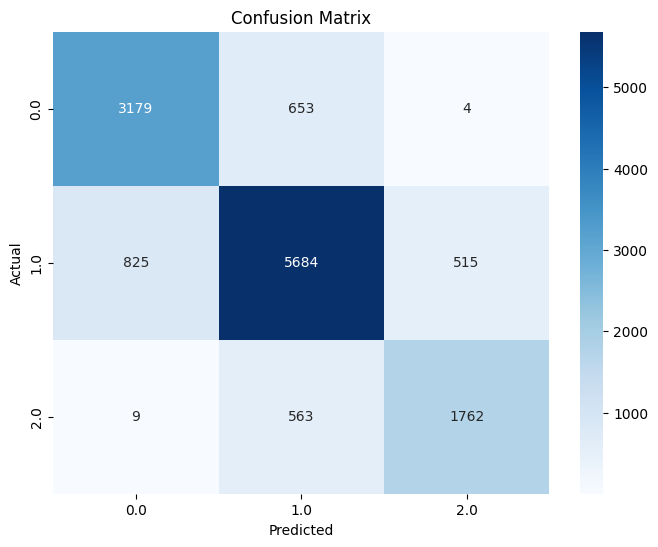

In [18]:
# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print(classification_report(y_test, y_pred))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# XGBoost (Gradient Boosting – Boosting)

In [19]:
!pip install xgboost

import xgboost as xgb

# Create an XGBoost classifier
xgb_classifier = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') # You can adjust hyperparameters

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:29:55] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Accuracy: 0.752766408973776
              precision    recall  f1-score   support

         0.0       0.75      0.75      0.75      3836
         1.0       0.77      0.79      0.78      7024
         2.0       0.69      0.64      0.67      2334

    accuracy                           0.75     13194
   macro avg       0.74      0.73      0.73     13194
weighted avg       0.75      0.75      0.75     13194



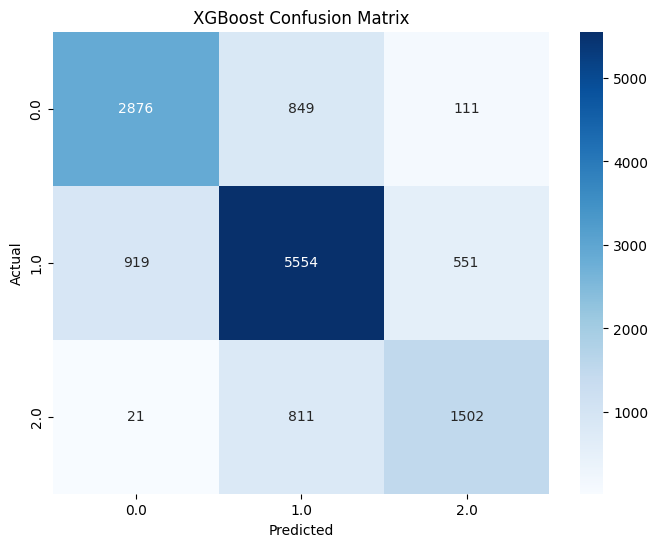

In [20]:
# Train the classifier
xgb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_classifier.predict(X_test)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb}")

print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()


# K-Nearest Neighbors (KNN)

In [21]:
from sklearn.neighbors import KNeighborsClassifier

# Create a KNN classifier (you can adjust n_neighbors)
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Train the classifier
knn_classifier.fit(X_train, y_train)

KNeighborsClassifier()

KNN Accuracy: 0.7746703046839473
              precision    recall  f1-score   support

         0.0       0.76      0.80      0.78      3836
         1.0       0.80      0.79      0.79      7024
         2.0       0.73      0.69      0.71      2334

    accuracy                           0.77     13194
   macro avg       0.76      0.76      0.76     13194
weighted avg       0.77      0.77      0.77     13194



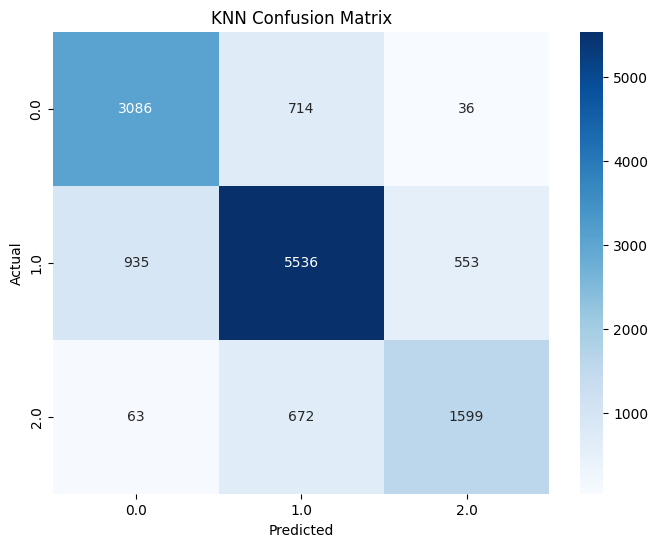

In [22]:
# Make predictions on the test set
y_pred_knn = knn_classifier.predict(X_test)

# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {accuracy_knn}")

print(classification_report(y_test, y_pred_knn))

# Confusion Matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()


In [23]:
#Compare 3 models